# Обучение модели ResNet18 для классификации AI vs Human Generated Images

Этот notebook содержит код для обучения модели ResNet18 на датасете Train_1 и оценки качества на Test_1.

## 1. Импорт библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Подготовка данных

In [5]:
class ImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.root_dir / self.data.iloc[idx]['file_name']
        image = Image.open(img_path).convert('RGB')
        label = self.data.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageDataset(
    csv_file='ai-vs-human-generated-dataset-hw/Train_1/train.csv',
    root_dir='ai-vs-human-generated-dataset-hw/Train_1',
    transform=train_transform
)

test_dataset = ImageDataset(
    csv_file='ai-vs-human-generated-dataset-hw/Test_1/test.csv',
    root_dir='ai-vs-human-generated-dataset-hw/Test_1',
    transform=test_transform
)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Train dataset size: 9993
Test dataset size: 3997


## 3. Создание модели ResNet18

In [7]:
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

print(f'Model architecture:')
print(model)

/mnt/d/ml-projects/test-project/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/d/ml-projects/test-project/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/mnt/d/ml-projects/test-project/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GeForce GTX 950M which is of cuda capability 5.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/mnt/d/ml-projects/test-project/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch 

Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): R

## 4. Определение функции потерь и оптимизатора

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

## 5. Функция обучения

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc='Training'):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1

## 6. Функция валидации

In [9]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    epoch_precision = precision_score(all_labels, all_preds, average='weighted')
    epoch_recall = recall_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall

## 7. Обучение модели

In [ ]:
from datetime import datetime
import json
from torch.utils.tensorboard import SummaryWriter


training_params = {
    'model': 'ResNet18',
    'batch_size': 32,
    'num_epochs': 10,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'scheduler': 'StepLR(step_size=5, gamma=0.1)',
    'train_dataset_size': len(train_dataset),
    'test_dataset_size': len(test_dataset),
    'timestamp': datetime.now().isoformat()
}

with open('train_base_model/training_params_v1.json', 'w') as f:
    json.dump(training_params, f, indent=4)

log_dir = f'train_base_model/runs/experiment_v1_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
writer = SummaryWriter(log_dir)

num_epochs = 10
train_losses = []
train_accs = []
train_f1s = []

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()

    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    writer.add_scalar('F1/train', train_f1, epoch)
    writer.add_scalar('Learning_rate', optimizer.param_groups[0]['lr'], epoch)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')

writer.close()


Epoch 1/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [15:04<00:00,  2.89s/it]


Train Loss: 0.4946, Acc: 0.7713, F1: 0.7713

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/313 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Training: 100%|██████████| 313/313 [02:00<00:00,  2.60it/s]


Train Loss: 0.4235, Acc: 0.8107, F1: 0.8106

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.2815, Acc: 0.8872, F1: 0.8872

Epoch 9/10
--------------------------------------------------


Training:   0%|          | 0/313 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Training: 100%|██████████| 313/313 [02:14<00:00,  2.32it/s]


Train Loss: 0.2752, Acc: 0.8875, F1: 0.8875

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/313 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Training: 100%|██████████| 313/313 [02:23<00:00,  2.18it/s]


Train Loss: 0.2655, Acc: 0.8889, F1: 0.8889


## 8. Оценка модели на тестовом датасете

In [ ]:
test_loss, test_acc, test_f1, test_precision, test_recall = validate(model, test_loader, criterion, device)

print('\n' + '='*50)
print('TEST RESULTS:')
print('='*50)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall: {test_recall:.4f}')

test_metrics = {
    'loss': test_loss,
    'accuracy': test_acc,
    'f1_score': test_f1,
    'precision': test_precision,
    'recall': test_recall
}

with open('train_base_model/test_metrics_v1.json', 'w') as f:
    json.dump(test_metrics, f, indent=4)

writer_test = SummaryWriter(log_dir)
writer_test.add_scalar('Loss/test', test_loss, 0)
writer_test.add_scalar('Accuracy/test', test_acc, 0)
writer_test.add_scalar('F1/test', test_f1, 0)
writer_test.add_scalar('Precision/test', test_precision, 0)
writer_test.add_scalar('Recall/test', test_recall, 0)
writer_test.close()

Validation:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validation: 100%|██████████| 125/125 [06:37<00:00,  3.18s/it]


TEST RESULTS:
Test Loss: 0.2577
Test Accuracy: 0.8967
Test F1 Score: 0.8963
Test Precision: 0.9020
Test Recall: 0.8967


In [ ]:
model_path = 'train_base_model/model/resnet18_model_v1.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'training_params': training_params,
    'test_metrics': test_metrics
}, model_path)

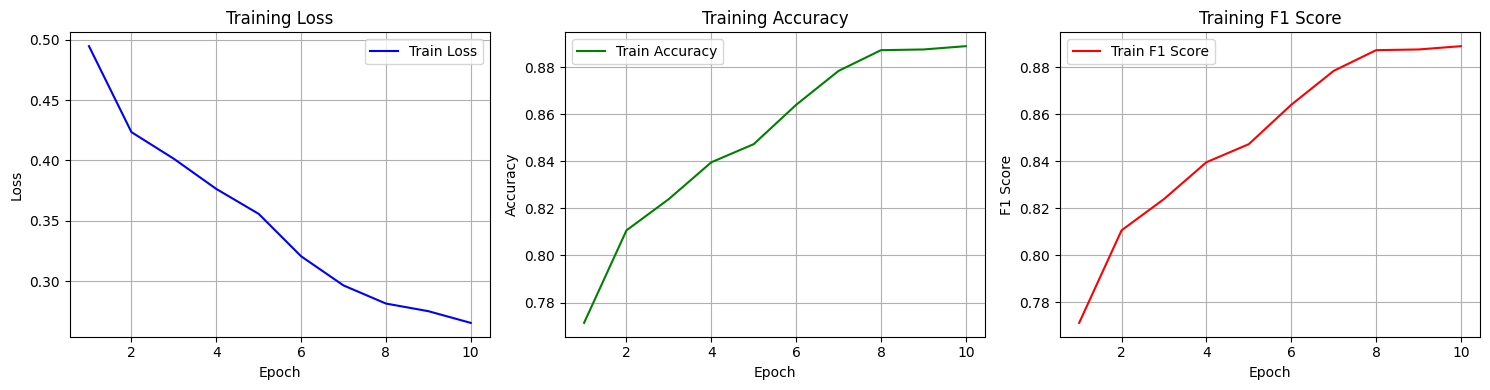

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(range(1, num_epochs+1), train_losses, 'b-', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, num_epochs+1), train_accs, 'g-', label='Train Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(range(1, num_epochs+1), train_f1s, 'r-', label='Train F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Training F1 Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 9. Дообучите модель на втором датасете и постройте DVC пайплайн

In [21]:
from pathlib import Path
from minio import Minio
from minio.error import S3Error
import torch


class S3ModelStorage:


    def __init__(
        self,
        endpoint="localhost:9000",
        access_key="minioadmin",
        secret_key="minioadmin",
        bucket="models",
        secure=False,
    ):
        self.bucket = bucket

        self.client = Minio(
            endpoint=endpoint,
            access_key=access_key,
            secret_key=secret_key,
            secure=secure,
        )

        self._ensure_bucket()

    def _ensure_bucket(self):
        """Create bucket if not exists"""
        try:
            if not self.client.bucket_exists(self.bucket):
                self.client.make_bucket(self.bucket)
                print(f"Bucket '{self.bucket}' created")
        except S3Error as e:
            raise RuntimeError(f"Bucket init error: {e}")


    def upload_model(self, local_model_path: str, s3_model_name: str):
        """
        Upload local model file to S3
        """

        local_model_path = Path(local_model_path)

        if not local_model_path.exists():
            raise FileNotFoundError(
                f"Model file not found: {local_model_path}"
            )

        try:
            self.client.fput_object(
                bucket_name=self.bucket,
                object_name=s3_model_name,
                file_path=str(local_model_path),
            )

            print(
                f"Model uploaded: "
                f"s3://{self.bucket}/{s3_model_name}"
            )

        except S3Error as e:
            raise RuntimeError(f"Upload error: {e}")


    def download_model(self, s3_model_name: str, local_model_path: str):
        """
        Download model from S3 before training
        """

        local_model_path = Path(local_model_path)
        local_model_path.parent.mkdir(parents=True, exist_ok=True)

        try:
            self.client.fget_object(
                bucket_name=self.bucket,
                object_name=s3_model_name,
                file_path=str(local_model_path),
            )

            print(
                f"Model downloaded: "
                f"s3://{self.bucket}/{s3_model_name}"
            )

            return str(local_model_path)

        except S3Error as e:
            raise RuntimeError(f"Download error: {e}")


    def save_checkpoint(
        self,
        model,
        optimizer,
        training_params,
        test_metrics,
        local_model_path,
    ):


        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "training_params": training_params,
            "test_metrics": test_metrics,
        }

        Path(local_model_path).parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        torch.save(checkpoint, local_model_path)

        print(f"Checkpoint saved: {local_model_path}")


    def load_checkpoint(
            self,
            model,
            optimizer,
            local_model_path,
            device="cpu",
        ):


        checkpoint = torch.load(
            local_model_path,
            map_location=device,
        )

        current_model_dict = model.state_dict()

        pretrained_dict = {
            k: v
            for k, v in checkpoint["model_state_dict"].items()
            if k in current_model_dict
            and v.shape == current_model_dict[k].shape
        }

        current_model_dict.update(pretrained_dict)

        model.load_state_dict(current_model_dict)

        print(
            f"Loaded {len(pretrained_dict)} layers "
            f"from checkpoint"
        )

        try:
            optimizer.load_state_dict(
                checkpoint["optimizer_state_dict"]
            )
            print("Optimizer loaded")

        except Exception:
            print(
                "Optimizer skipped "
                "(architecture changed)"
            )

        return {
            "training_params": checkpoint.get(
                "training_params", {}
            ),
            "test_metrics": checkpoint.get(
                "test_metrics", {}
            ),
        }
    
    def load_model_from_s3(
        self,
        model,
        optimizer,
        s3_model_name,
        local_model_path="/tmp/model.pth",
        device="cpu",
    ):

        self.download_model(
            s3_model_name,
            local_model_path,
        )

        return self.load_checkpoint(
            model=model,
            optimizer=optimizer,
            local_model_path=local_model_path,
            device=device,
        )

    def save_model_to_s3(
        self,
        model,
        optimizer,
        training_params,
        test_metrics,
        s3_model_name,
        local_model_path="/tmp/model.pth",
    ):

        self.save_checkpoint(
            model=model,
            optimizer=optimizer,
            training_params=training_params,
            test_metrics=test_metrics,
            local_model_path=local_model_path,
        )

        self.upload_model(
            local_model_path=local_model_path,
            s3_model_name=s3_model_name,
        )

    def list_models(self):

        objects = self.client.list_objects(
            self.bucket,
            recursive=True,
        )

        return [obj.object_name for obj in objects]

In [23]:
s3_storage = S3ModelStorage()

s3_storage.save_model_to_s3(
    model=model,
    optimizer=optimizer,
    training_params=training_params,
    test_metrics=test_metrics,
    s3_model_name="train_base_model/model/resnet18_model_v1.pth",
    local_model_path="/tmp/resnet18_model_v1.pth",
)


Checkpoint saved: /tmp/resnet18_model_v1.pth
Model uploaded: s3://models/train_base_model/model/resnet18_model_v1.pth


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(p=0.25)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset_v2 = ImageDataset(
    csv_file='ai-vs-human-generated-dataset-hw/Train_2/train.csv',
    root_dir='ai-vs-human-generated-dataset-hw/Train_2',
    transform=train_transform
)

test_dataset_v2 = ImageDataset(
    csv_file='ai-vs-human-generated-dataset-hw/Test_2/test.csv',
    root_dir='ai-vs-human-generated-dataset-hw/Test_2',
    transform=test_transform
)

batch_size = 32
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader_v2 = DataLoader(test_dataset_v2, batch_size=batch_size, shuffle=False, num_workers=4)

print(f'Train_2 dataset size: {len(train_dataset_v2)}')
print(f'Test_2 dataset size: {len(test_dataset_v2)}')


Train_2 dataset size: 3997
Test_2 dataset size: 2000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [24]:
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.Linear(256, 256),
    nn.Linear(256, 2)
)


metadata = s3_storage.load_model_from_s3(
    model=model,
    optimizer=optimizer,
    s3_model_name="train_base_model/model/resnet18_model_v1.pth",
    local_model_path="/tmp/resnet18_model_v1.pth",
    device="cpu",
)

print(metadata)

Model downloaded: s3://models/train_base_model/model/resnet18_model_v1.pth
Loaded 126 layers from checkpoint
Optimizer loaded
{'training_params': {'model': 'ResNet18', 'batch_size': 32, 'num_epochs': 10, 'learning_rate': 0.001, 'optimizer': 'Adam', 'scheduler': 'StepLR(step_size=5, gamma=0.1)', 'train_dataset_size': 9993, 'test_dataset_size': 3997, 'timestamp': '2026-05-25T12:17:20.711162'}, 'test_metrics': {'loss': 0.2576543030617742, 'accuracy': 0.8966725043782837, 'f1_score': 0.8963186795664655, 'precision': 0.9020303612216763, 'recall': 0.8966725043782837}}


In [25]:
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

In [132]:
finetune_params = {
    'model': 'ResNet18_FineTuned',
    'base_model': 'resnet18_model_v1.pth',
    'batch_size': 32,
    'num_epochs': 5,
    'learning_rate': 1e-4,
    'optimizer': 'AdamW',
    'scheduler': 'CosineAnnealingLR(optimizer,T_max=finetune_params["num_epochs"])',
    'train_dataset_size': len(train_dataset_v2),
    'test_dataset_size': len(test_dataset_v2),
    'timestamp': datetime.now().isoformat(),
}

In [ ]:
with open('finetune/finetune_params_v2.json', 'w') as f:
    json.dump(finetune_params, f, indent=4)

In [134]:
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=finetune_params['learning_rate'],
    weight_decay=1e-4
)
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=finetune_params['num_epochs']
)

In [135]:
def train_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_idx, (images, labels) in enumerate(tqdm(dataloader, desc=f'Training Epoch {epoch}')):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Логирование batch-level метрик
        if batch_idx % 50 == 0:
            writer.add_scalar('Batch/Loss', loss.item(), epoch * len(dataloader) + batch_idx)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1

def validate(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f'Validation Epoch {epoch}'):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    epoch_precision = precision_score(all_labels, all_preds, average='weighted')
    epoch_recall = recall_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall

In [ ]:
model_path_v2 = 'finetune/model/resnet18_model_v2_finetuned.pth'


log_dir = f'finetune/runs/finetune_v2_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
writer = SummaryWriter(log_dir)
num_epochs = finetune_params['num_epochs']
train_losses = []
train_accs = []
train_f1s = []
val_losses = []
val_accs = []
val_f1s = []
val_precisions = []
val_recalls = []
best_val_loss = float('inf')
best_epoch = 0

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_epoch(model, train_loader_v2, criterion, optimizer, device, epoch+1)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    val_loss, val_acc, val_f1, val_precision, val_recall = validate(model, test_loader_v2, criterion, device, epoch+1)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)

    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Loss/val', val_loss, epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    writer.add_scalar('Accuracy/val', val_acc, epoch)
    writer.add_scalar('F1/train', train_f1, epoch)
    writer.add_scalar('F1/val', val_f1, epoch)
    writer.add_scalar('Precision/val', val_precision, epoch)
    writer.add_scalar('Recall/val', val_recall, epoch)
    writer.add_scalar('Learning_rate', optimizer.param_groups[0]['lr'], epoch)

    print(f'Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')
    print(f'Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), model_path_v2)
    scheduler.step()

writer.close()


Epoch 1/5
--------------------------------------------------


Training Epoch 1:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validation Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potentia

Train - Loss: 0.4050, Acc: 0.8156, F1: 0.8155
Val   - Loss: 0.3409, Acc: 0.8410, F1: 0.8386, Precision: 0.8635, Recall: 0.8410

Epoch 2/5
--------------------------------------------------


Training Epoch 2:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validation Epoch 2:   0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potentia

Train - Loss: 0.3713, Acc: 0.8349, F1: 0.8349
Val   - Loss: 0.3138, Acc: 0.8620, F1: 0.8607, Precision: 0.8766, Recall: 0.8620

Epoch 3/5
--------------------------------------------------


...

Train - Loss: 0.3572, Acc: 0.8471, F1: 0.8471
Val   - Loss: 0.3144, Acc: 0.8585, F1: 0.8572, Precision: 0.8734, Recall: 0.8585

Epoch 4/5
--------------------------------------------------


Training Epoch 4:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validation Epoch 4:   0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potentia

Train - Loss: 0.3495, Acc: 0.8494, F1: 0.8494
Val   - Loss: 0.2832, Acc: 0.8805, F1: 0.8802, Precision: 0.8842, Recall: 0.8805

Epoch 5/5
--------------------------------------------------


Training Epoch 5:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validation Epoch 5:   0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potentia

Train - Loss: 0.3494, Acc: 0.8439, F1: 0.8439
Val   - Loss: 0.2694, Acc: 0.8925, F1: 0.8925, Precision: 0.8930, Recall: 0.8925


In [137]:
torch.save(model.state_dict(), model_path_v2)

In [ ]:
best_model_path = 'finetune/model/resnet18_model_v2_finetuned.pth'
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.Linear(256, 256),
    nn.Linear(256, 2)
)

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint)
model = model.to(device)

model.eval()
test_loss, test_acc, test_f1, test_precision, test_recall = validate(model, test_loader_v2, criterion, device, 'test_2_v2')


test_metrics_v2 = {
    'loss': test_loss,
    'accuracy': test_acc,
    'f1_score': test_f1,
    'precision': test_precision,
    'recall': test_recall,
    'training_history': {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'train_f1s': train_f1s,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'val_f1s': val_f1s,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls
    }
}

with open('finetune/test_metrics_v2.json', 'w') as f:
    json.dump(test_metrics_v2, f, indent=4)

Validation Epoch test_2_v2:   0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validation Epoch test_2_v2: 100%|██████████| 63/63 [00:22<00:00,  2.83it/s]


In [ ]:
model_path = 'train_base_model/model/resnet18_model_v1.pth'
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

model.eval()
test_loss, test_acc, test_f1, test_precision, test_recall = validate(model, test_loader_v2, criterion, device, 'test_2_v1')


test_metrics_v1 = {
    'loss': test_loss,
    'accuracy': test_acc,
    'f1_score': test_f1,
    'precision': test_precision,
    'recall': test_recall
}

with open('finetune/test_metrics_v1.json', 'w') as f:
    json.dump(test_metrics_v2, f, indent=4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Validation Epoch test_2_v1:   0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze i

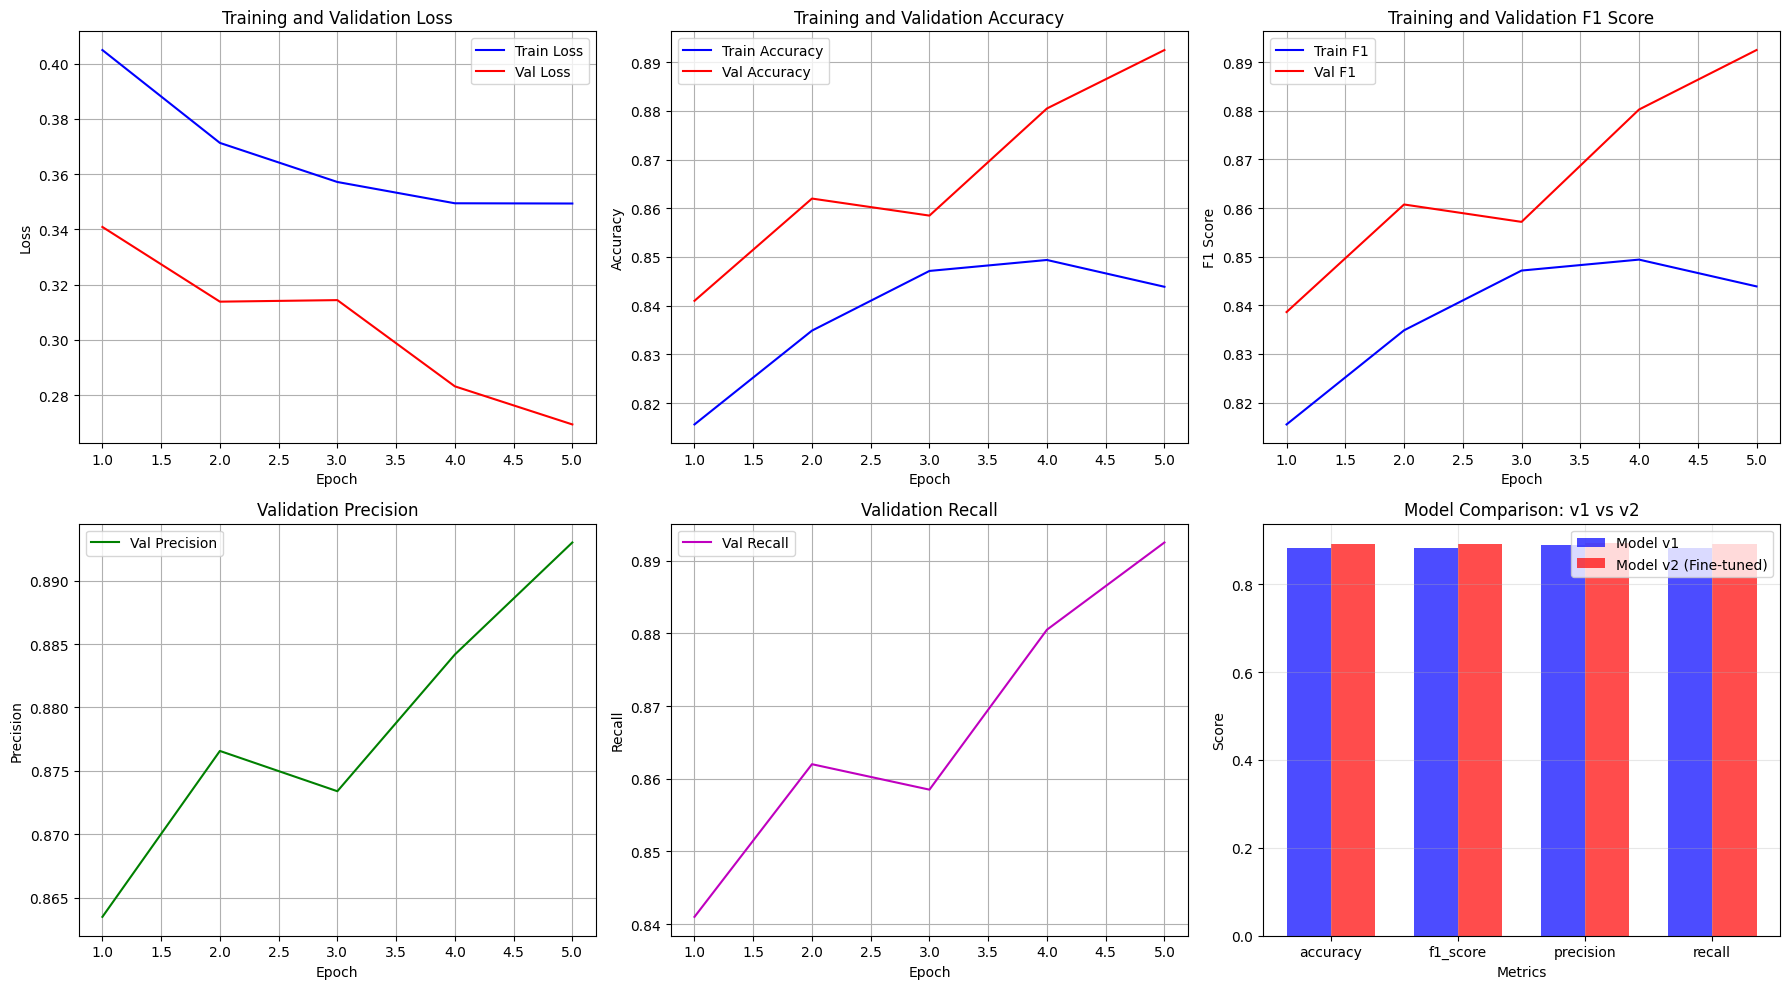

In [140]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(range(1, num_epochs+1), train_losses, 'b-', label='Train Loss')
axes[0, 0].plot(range(1, num_epochs+1), val_losses, 'r-', label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(range(1, num_epochs+1), train_accs, 'b-', label='Train Accuracy')
axes[0, 1].plot(range(1, num_epochs+1), val_accs, 'r-', label='Val Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# F1 Score
axes[0, 2].plot(range(1, num_epochs+1), train_f1s, 'b-', label='Train F1')
axes[0, 2].plot(range(1, num_epochs+1), val_f1s, 'r-', label='Val F1')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('F1 Score')
axes[0, 2].set_title('Training and Validation F1 Score')
axes[0, 2].legend()
axes[0, 2].grid(True)

# Precision
axes[1, 0].plot(range(1, num_epochs+1), val_precisions, 'g-', label='Val Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Validation Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(range(1, num_epochs+1), val_recalls, 'm-', label='Val Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Validation Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Сравнение с v1

metrics = ['accuracy', 'f1_score', 'precision', 'recall']
v1_values = [test_metrics_v1.get(m, 0) for m in metrics]
v2_values = [test_metrics_v2.get(m, 0) for m in metrics]

x = np.arange(len(metrics))
width = 0.35

axes[1, 2].bar(x - width/2, v1_values, width, label='Model v1', color='blue', alpha=0.7)
axes[1, 2].bar(x + width/2, v2_values, width, label='Model v2 (Fine-tuned)', color='red', alpha=0.7)
axes[1, 2].set_xlabel('Metrics')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Model Comparison: v1 vs v2')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import boto3
from minio import Minio

class S3ModelStorage:
    def __init__(self, endpoint="localhost:9000", access_key="minioadmin", secret_key="minioadmin", bucket="models", secure=False):
        self.client = Minio(
            endpoint=endpoint,
            access_key=access_key,
            secret_key=secret_key,
            secure=secure
        )
        self.bucket = bucket
        self._ensure_bucket()

    def _ensure_bucket(self):
        if not self.client.bucket_exists(self.bucket):
            self.client.make_bucket(self.bucket)
            print(f"Bucket '{self.bucket}' created")

    def upload_model(self, model_path, model_name):
        """Upload model to S3"""
        self.client.fput_object(
            self.bucket, model_name, model_path
        )
        print(f"Model uploaded to {self.bucket}/{model_name}")

    def download_model(self, model_name, local_path):
        """Download model from S3"""
        try:
            self.client.fget_object(
                self.bucket, model_name, local_path
            )
            print(f"Model downloaded from {self.bucket}/{model_name}")
            return True
        except Exception as e:
            print(f"Error downloading model: {e}")
            return False

    def list_models(self):
        """List all models in bucket"""
        objects = self.client.list_objects(self.bucket)
        return [obj.object_name for obj in objects]

s3_storage = S3ModelStorage()

In [ ]:
model = models.resnet18(pretrained=False)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.Linear(256, 256),
    nn.Linear(256, 2)
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=finetune_params['learning_rate'],
    weight_decay=1e-4
)

s3_storage.save_model_to_s3(
    model=model,
    optimizer=optimizer,
    training_params=training_params,
    test_metrics=test_metrics,
    s3_model_name="finetune/model/resnet18_model_v2_finetuned.pth",
    local_model_path="/tmp/resnet18_model_v2_finetuned.pth",
)

## 10. Напишите вывод о полученных результатах

Дообученная модель сохранила высокое качество на втором датасете. Артефакты моделей сохранены в S3, метрики залогированы в TensorBoard, пайплайн воспроизводим через DVC.


                    +------------+
                    | train_base |
                    +------------+
                  ***            ***
                **                  ***
              **                       **
     +----------+                        **
     | finetune |**                       *
     +----------+  *****                  *
           *            ******            *
           *                  *****       *
           *                       ***    *
+--------------------+            +---------------+
| evaluate_finetuned |            | upload_models |
+--------------------+            +---------------+

...